# 06 · Distributed Target Tracking
**Companion to the lecture:** *Distributed Target Tracking* — Felix Govaers, FUSION Boot Camp 2026.

> ⚠️ The slides for this lecture are **not** in the PDF. This notebook is based on the canonical distributed-fusion literature.

In **distributed** tracking, several nodes/sensors run local filters and exchange tracks rather than raw measurements. 
The central challenge: **hidden correlation** between the tracks (shared process noise, common information) — naive fusion becomes over-confident.

## A. The Information Filter
The information form of the Kalman filter replaces $(\hat x, P)$ with an **information vector** $y=P^{-1}\hat x$ and an 
**information matrix** $Y=P^{-1}$. Its advantage: **the measurement update becomes addition** — ideal for distributed fusion:
$$Y_{k|k}=Y_{k|k-1}+H^TR^{-1}H, \qquad y_{k|k}=y_{k|k-1}+H^TR^{-1}z$$
Several independent sensors simply **add** their information contributions — a direct generalization of the fusion equation 
from notebook 01 ($Y_F=Y_1+Y_2$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(5)

def fuse_information(estimates):
    """Optimal fusion of *independent* estimates in information form."""
    Y = sum(np.linalg.inv(P) for _,P in estimates)
    y = sum(np.linalg.inv(P)@x for x,P in estimates)
    P = np.linalg.inv(Y); return P@y, P

# three sensors measure the 2-D position of the same target, with different covariances
true = np.array([3.,2.])
Ps = [np.array([[5,1.],[1,2]]), np.array([[2,-.5],[-.5,4]]), np.array([[3,0.],[0,1]])]
ests = [(true + np.linalg.cholesky(P)@rng.standard_normal(2), P) for P in Ps]
xf, Pf = fuse_information(ests)
print('fused estimate:', np.round(xf,2), ' det(P_fused)=%.3f' % np.linalg.det(Pf))
for i,(_,P) in enumerate(ests): print(f'  det(P_{i})={np.linalg.det(P):.3f}')
print('-> the fused information (small det) is better than any single sensor.')

fused estimate: [3.33 1.64]  det(P_fused)=0.515
  det(P_0)=9.000
  det(P_1)=7.750
  det(P_2)=3.000
-> the fused information (small det) is better than any single sensor.


## B. The problem: hidden correlation and naive fusion
Tracks from different nodes **are not independent** — they share the process noise of the same target, and sometimes 
shared past information (rumor propagation / double counting). Naive 'information' fusion ignores this and yields a 
covariance that is **too small** (over-confident), i.e. an **inconsistent** filter.

In [2]:
# simulation: two tracks with shared process noise (true correlation)
mc=3000; common=0.8   # fraction of shared variance
naive_in, ci_in = 0, 0
for _ in range(mc):
    e_common = np.sqrt(common)*rng.standard_normal(2)
    P1=P2=np.eye(2)
    x1=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    x2=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    # naive (assumes independence)
    xf,Pf=fuse_information([(x1,P1),(x2,P2)])
    d=(xf-true); nees=float(d@np.linalg.inv(Pf)@d)
    naive_in += nees<=5.99   # chi2_2 95%
naive_cov = naive_in/mc
print(f'naive fusion 95%% confidence-region coverage: {naive_cov:.1%} (should be ~95%% -- below that = over-confident)')

naive fusion 95%% confidence-region coverage: 81.0% (should be ~95%% -- below that = over-confident)


## C. Covariance Intersection (CI)
When **the correlation is unknown**, CI guarantees consistency without assuming independence. It combines in information 
form with a weight $\omega\in[0,1]$:
$$P_{CI}^{-1}=\omega P_1^{-1}+(1-\omega)P_2^{-1}, \qquad P_{CI}^{-1}\hat x_{CI}=\omega P_1^{-1}\hat x_1+(1-\omega)P_2^{-1}\hat x_2$$
$\omega$ is usually chosen to minimize $\det(P_{CI})$. The result is **conservative** (not over-confident) for any correlation.

In [3]:
def covariance_intersection(x1,P1,x2,P2):
    I1,I2=np.linalg.inv(P1),np.linalg.inv(P2); best=None
    for w in np.linspace(0.01,0.99,99):
        Pi=np.linalg.inv(w*I1+(1-w)*I2); d=np.linalg.det(Pi)
        if best is None or d<best[0]: best=(d,w,Pi)
    _,w,Pci=best
    xci=Pci@(w*I1@x1+(1-w)*I2@x2)
    return xci,Pci,w

ci_in=0
for _ in range(mc):
    e_common=np.sqrt(common)*rng.standard_normal(2)
    x1=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    x2=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    xci,Pci,_=covariance_intersection(x1,np.eye(2),x2,np.eye(2))
    d=(xci-true); nees=float(d@np.linalg.inv(Pci)@d)
    ci_in += nees<=5.99
print(f'naive coverage: {naive_cov:.1%}   |   CI coverage: {ci_in/mc:.1%}  (CI is consistent/conservative)')

naive coverage: 81.0%   |   CI coverage: 95.2%  (CI is consistent/conservative)


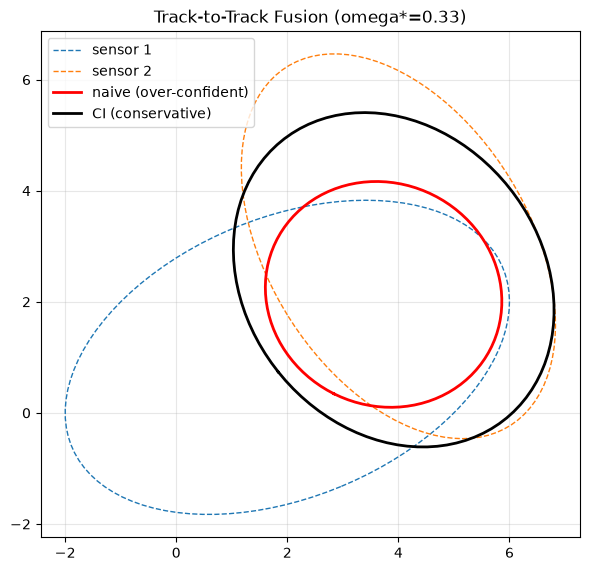

In [4]:
# visual comparison of the ellipses: naive is too small, CI is conservative
x1=np.array([2.,1.]); x2=np.array([4.,3.]); P1=np.array([[4,1.],[1,2]]); P2=np.array([[2,-1.],[-1,3]])
xn,Pn=fuse_information([(x1,P1),(x2,P2)]); xci,Pci,w=covariance_intersection(x1,P1,x2,P2)
def ell(P,m,**k):
    th=np.linspace(0,2*np.pi,100); v,Q=np.linalg.eigh(P)
    e=Q@np.diag(2*np.sqrt(v))@np.array([np.cos(th),np.sin(th)]); return e[0]+m[0],e[1]+m[1]
plt.figure(figsize=(6,6))
for P,m,st,lab in [(P1,x1,'C0--','sensor 1'),(P2,x2,'C1--','sensor 2'),
                   (Pn,xn,'r-','naive (over-confident)'),(Pci,xci,'k-','CI (conservative)')]:
    ex,ey=ell(P,m); plt.plot(ex,ey,st,lw=2 if st in('r-','k-') else 1,label=lab)
plt.gca().set_aspect('equal'); plt.legend(); plt.grid(alpha=.3)
plt.title(f'Track-to-Track Fusion (omega*={w:.2f})'); plt.tight_layout(); plt.show()

## Summary
* **The information filter** turns fusion into addition — the basis for distributed fusion; for independent sensors: $Y_F=\sum Y_i$.
* **Hidden correlation** between tracks makes naive fusion over-confident (inconsistent).
* **Covariance Intersection** guarantees consistency for any unknown correlation — at the cost of a more conservative estimate.
* Further topics in the lecture: distributed/decentralized Kalman, accumulated state densities, sensor networks.